# **Regresión Dinámica Directa para doble péndulo**

In [1]:
import math
import numpy as np
import keras 
import tensorflow as tf
import datetime
import json
import os
#from tensorflow import keras
from keras.models import Sequential #One of the most important classes in tensorflow, used to creare NN (Named after NN as a sequence of layers)
from keras.layers import Input, Dense, LSTM, BatchNormalization, Dropout, InputLayer #Dense layer means that one neuron in one layer is connected to all neurons in the next layer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from keras.regularizers import l2, l1, l1_l2
from sklearn.utils import shuffle
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline
from scipy.ndimage import gaussian_filter1d
from datetime import datetime

#tf.config.optimizer.set_jit(False)

#from keras_tuner import RandomSearch

2025-07-16 12:12:11.663462: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-16 12:12:11.663484: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-16 12:12:11.663490: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = '2lpr_jointmovement_2025_07_10-17_47_16.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_1 = pd.read_csv(body)
df_1.head(10)


def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = '2lpr_cartesianmovement_2025_07_10-17_47_16.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_2 = pd.read_csv(body)
df_2.head(10)



def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = '2lpr_jointmovement_2025_07_10-13_47_41.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_3 = pd.read_csv(body)
df_3.head(10)


datos_2LRP_joint = df_3
datos_2LRP_cart = df_2

In [3]:
#datos_2LRP_joint = pd.read_csv(f'./2lpr_jointmovement_2025_07_10-13_47_41.csv',delimiter=',', encoding="utf-8", skipinitialspace=True)
#datos_2LRP_cart = pd.read_csv(f'./2lpr_cartesianmovement_2025_07_10-13_47_41.csv',delimiter=',', encoding="utf-8", skipinitialspace=True)

In [4]:
time_joint = datos_2LRP_joint.iloc[:,1].values

pos_j1_joint = datos_2LRP_joint.iloc[:,2].values
pos_j2_joint = datos_2LRP_joint.iloc[:,3].values

vels_j1_joint = datos_2LRP_joint.iloc[:,4].values
vels_j2_joint = datos_2LRP_joint.iloc[:,5].values

accs_j1_joint = datos_2LRP_joint.iloc[:,6].values
accs_j2_joint = datos_2LRP_joint.iloc[:,7].values

torq_j1_joint = datos_2LRP_joint.iloc[:,8].values
torq_j2_joint = datos_2LRP_joint.iloc[:,9].values

In [5]:
time_cart = datos_2LRP_cart.iloc[:,1].values

pos_j1_cart = datos_2LRP_cart.iloc[:,2].values
pos_j2_cart = datos_2LRP_cart.iloc[:,3].values

vels_j1_cart = datos_2LRP_cart.iloc[:,4].values
vels_j2_cart = datos_2LRP_cart.iloc[:,5].values

accs_j1_cart = datos_2LRP_cart.iloc[:,6].values
accs_j2_cart = datos_2LRP_cart.iloc[:,7].values

torq_j1_cart = datos_2LRP_cart.iloc[:,8].values
torq_j2_cart = datos_2LRP_cart.iloc[:,9].values

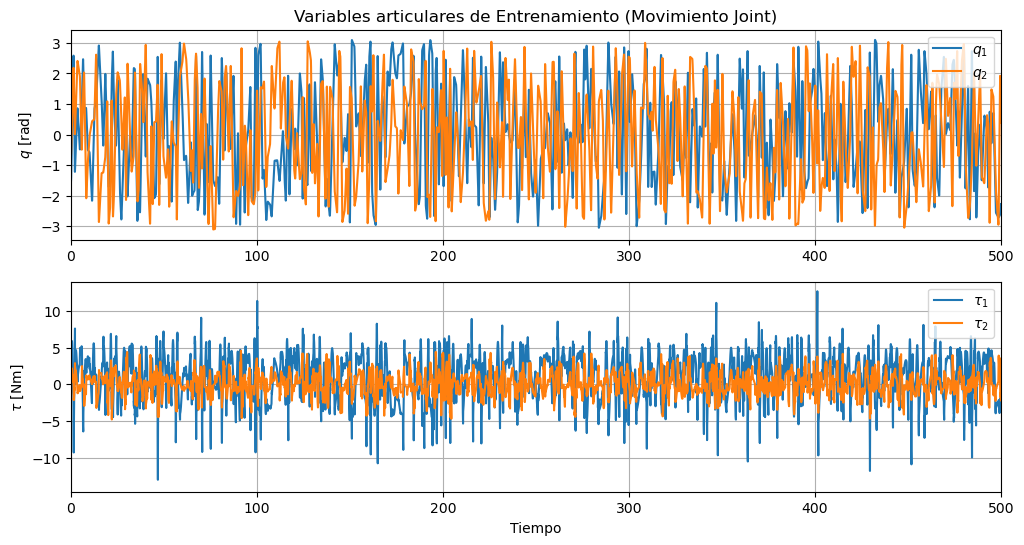

In [6]:
num_links = 2

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 6))  # Cambia el tamaño según tus necesidades
plt.subplot(2,1,1)
plt.plot(time_joint, pos_j1_joint)
plt.plot(time_joint, pos_j2_joint)
plt.xlim(0, 500)
plt.legend([r'$q_1$', r'$q_2$'],loc='upper right', fontsize=10);  plt.ylabel(r"$q$ [rad]")
plt.grid(True)
plt.title('Variables articulares de Entrenamiento (Movimiento Joint)')
plt.subplot(2,1,2)
plt.plot(time_joint, torq_j1_joint)
plt.plot(time_joint, torq_j2_joint)
plt.xlim(0, 500)
plt.legend([r'$\tau_{1}$', r'$\tau_{2}$'],loc='upper right', fontsize=10); plt.xlabel('Tiempo'); plt.ylabel(r"$\tau$ [Nm]")
plt.grid(True)
plt.show()

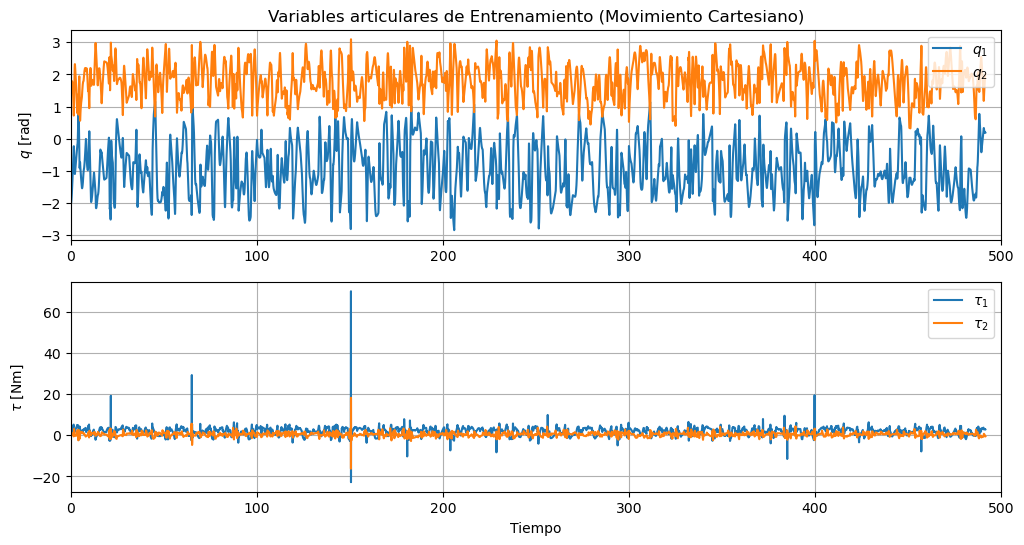

In [7]:
num_links = 2

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 6))  # Cambia el tamaño según tus necesidades
plt.subplot(2,1,1)
plt.plot(time_cart, pos_j1_cart)
plt.plot(time_cart, pos_j2_cart)
plt.xlim(0, 500)
plt.legend([r'$q_1$', r'$q_2$'],loc='upper right', fontsize=10);  plt.ylabel(r"$q$ [rad]")
plt.grid(True)
plt.title('Variables articulares de Entrenamiento (Movimiento Cartesiano)')
plt.subplot(2,1,2)
plt.plot(time_cart, torq_j1_cart)
plt.plot(time_cart, torq_j2_cart)
plt.xlim(0, 500)
plt.legend([r'$\tau_{1}$', r'$\tau_{2}$'],loc='upper right', fontsize=10); plt.xlabel('Tiempo'); plt.ylabel(r"$\tau$ [Nm]")
plt.grid(True)
plt.show()

# **Red neuronal Secuencial (Same-step approach)**:

No es el entrenamiento de las redes lo que se compara, sino la calidad de los resultados finales. Cada red tiene una técnica de entrenamiento: las secuenciales no aprenden la correlación entre muestras, entonces es mejor entrenarlas con muestras descorrelacionadas -> ruido blanco, en cambio, las redes LSTM aprenden la historia y evolución del sistema (la correlación entre muestras), van a necesitar muestras ordenadas, secuencia de tiempo.

Problema Dinámico INVERSO: Dados las posiciones, velocidades y aceleraciones joint, obtener el valor de los torques necesarios para mantener esa posición.

En el método de same step approach, tengo que tener en cuenta cómo se describe la fórmula a analizar. Para el problema inverso, tengo en cuenta que la expresión de la dinámica es una función contínua, pero todo refiere al mismo instante de tiempo, ya que dadas las posiciones, velocidades y aceleraciones, el valor de torque obtenido es aquel para mantener esta posición. Entonces los valores de posición y velocidad son para el instante de tiempo del torque resultante. 

Para el caso de la posición, no tiene sentido el same step approach, porque quiero calcular la posición siguiente

# **Red neuronal LSTM con Dataset JOINT**

In [8]:
#Inputs ---> uk=[qTk-1  d_qTk-1  tauTk]T
time = datos_2LRP_joint.iloc[1:-1,1].values

pos_j1 = datos_2LRP_joint.iloc[:-2,2].values
pos_j2 = datos_2LRP_joint.iloc[:-2,3].values

vels_j1 = datos_2LRP_joint.iloc[:-2,4].values
vels_j2 = datos_2LRP_joint.iloc[:-2,5].values

torq_j1 = datos_2LRP_joint.iloc[1:-1,8].values
torq_j2 = datos_2LRP_joint.iloc[1:-1,9].values

accs_j1 = datos_2LRP_joint.iloc[1:-1,6].values
accs_j2 = datos_2LRP_joint.iloc[1:-1,7].values

next_pos_j1 = datos_2LRP_joint.iloc[1:-1,2].values
next_pos_j2 = datos_2LRP_joint.iloc[1:-1,3].values

In [9]:
inputs = np.vstack((pos_j1, pos_j2, torq_j1, torq_j2)).T
#inputs = np.vstack((pos_j1, pos_j2, torq_j1, torq_j2)).T
outputs = np.vstack((next_pos_j1, next_pos_j2)).T

In [10]:
inputs.shape

(501535, 4)

In [11]:
def create_lstm_sequences(inputs, outputs, time_joint, window_size=6, split=0.8):
    """
    Genera secuencias de entrada y salida para una LSTM a partir de los datos de posición, velocidad, aceleración y torque.
    
    Args:
        inputs: Matriz de entrada que contiene las posiciones, velocidades y aceleraciones.
        outputs: Matriz de salida que contiene los torques.
        time_joint: Vector de tiempo asociado a los datos.
        window_size: Tamaño de la ventana de tiempo para la LSTM.
        split: Proporción del dataset que se utiliza para entrenamiento (el resto para prueba).
        
    Returns:
        X_train: Secuencias de entrada para entrenamiento.
        Y_train: Secuencias de salida para entrenamiento.
        X_test: Secuencias de entrada para prueba.
        Y_test: Secuencias de salida para prueba.
        t_test: Vector de tiempo correspondiente al conjunto de prueba.
    """
    # Preparar las secuencias de entrada y salida usando ventanas deslizantes
    input_sequences = []
    output_sequences = []
    
    for i in range(len(inputs) - window_size):
        input_sequences.append(inputs[i:i+window_size])
        output_sequences.append(outputs[i+window_size])
    
    # Convertir a arrays numpy
    X = np.array(input_sequences)
    Y = np.array(output_sequences)
    
    # Dividir en conjuntos de entrenamiento y prueba
    if split > 0 and split < 1:
        idx_split = int(split * len(X))
        X_train, X_test = X[:idx_split], X[idx_split:]
        Y_train, Y_test = Y[:idx_split], Y[idx_split:]
        t_test = time_joint[idx_split:-window_size-len(inputs)]
    else:
        X_train, X_test = X, None
        Y_train, Y_test = Y, None
        t_test = time_joint[:-window_size-len(inputs)]
    
    return X_train, Y_train, X_test, Y_test, t_test


In [12]:
def create_lstm_sequences(inputs, outputs, time_joint, window_size=6, split_train=0.7, split_val=0.15):
    """
    Genera secuencias de entrada y salida para una LSTM, dividiendo el dataset en entrenamiento, validación y test.

    Args:
        inputs (np.ndarray): Matriz (N, F_in) de entradas (posiciones, velocidades, aceleraciones).
        outputs (np.ndarray): Matriz (N, F_out) de salidas (torques).
        time_joint (np.ndarray): Vector (N,) de tiempo asociado a los datos.
        window_size (int): Tamaño de la ventana de tiempo para la LSTM.
        split_train (float): Proporción para el conjunto de entrenamiento (ej: 0.7).
        split_val (float): Proporción para validación (ej: 0.15). El resto se usará para test.

    Returns:
        X_train, Y_train: Datos de entrenamiento.
        X_val, Y_val: Datos de validación.
        X_test, Y_test: Datos de prueba.
        t_val, t_test: Tiempos asociados a Y_val y Y_test.
    """
    assert 0 < split_train < 1, "split_train debe estar entre 0 y 1"
    assert 0 <= split_val < 1, "split_val debe estar entre 0 y 1"
    assert split_train + split_val < 1, "La suma split_train + split_val debe ser menor que 1"

    # Construcción de ventanas
    input_sequences = []
    output_sequences = []
    time_targets = []

    for i in range(len(inputs) - window_size):
        input_sequences.append(inputs[i:i + window_size])
        output_sequences.append(outputs[i + window_size])
        time_targets.append(time_joint[i + window_size])

    X = np.array(input_sequences)
    Y = np.array(output_sequences)
    T = np.array(time_targets)

    # Índices de corte
    n_total = len(X)
    idx_train = int(split_train * n_total)
    idx_val = int((split_train + split_val) * n_total)

    # División de datos
    X_train, Y_train = X[:idx_train], Y[:idx_train]
    X_val, Y_val = X[idx_train:idx_val], Y[idx_train:idx_val]
    X_test, Y_test = X[idx_val:], Y[idx_val:]

    t_val = T[idx_train:idx_val]
    t_test = T[idx_val:]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test, t_val, t_test


In [13]:
#Para las LSTM es necesario que defin
# N_segments = 50 #Puntos destino de movimiento joint

# Definir el tamaño de la ventana de tiempo para las secuencias
w_size =20

# Aplicar StandardScaler
scaler1_LSTM = StandardScaler() #MinMaxScaler()#feature_range=(0, 1)) #RobustScaler() #MinMaxScaler() #StandardScaler()
inputs = scaler1_LSTM.fit_transform(inputs)

scaler2_LSTM = StandardScaler() #MinMaxScaler()#feature_range=(0, 1)) #RobustScaler() #MinMaxScaler() #StandardScaler()
outputs = scaler2_LSTM.fit_transform(outputs)

#X_train_LSTM, y_train_LSTM, X_val_LSTM, y_val_LSTM, t_val_LSTM  = create_lstm_sequences(inputs, outputs, time_joint, window_size=w_size, split=0.7)

X_train_LSTM, y_train_LSTM, X_val_LSTM, y_val_LSTM, X_test_LSTM, y_test_LSTM, t_val_LSTM, t_test_LSTM = create_lstm_sequences(
    inputs, outputs, time_joint,
    window_size=w_size,
    split_train=0.7,
    split_val=0.15
)

In [14]:
X_train_LSTM.shape
#print(X_train_LSTM[0:4],y_train_LSTM[0:4])
print(X_train_LSTM.shape)
print(X_val_LSTM.shape)
print(X_test_LSTM.shape)

(351060, 20, 4)
(75227, 20, 4)
(75228, 20, 4)


⚙️ Creando nuevo modelo...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30)                4200      
                                                                 
 dense (Dense)               (None, 2)                 62        
                                                                 
Total params: 4262 (16.65 KB)
Trainable params: 4262 (16.65 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/700
2743/2743 [==============================] - 28s 9ms/step - loss: 0.1107 - mae: 0.1761 - val_loss: 0.0030 - val_mae: 0.0380
Epoch 2/700
  15/2743 [..............................] - ETA: 20s - loss: 0.0031 - mae: 0.0388

/opt/conda/envs/Python-RT24.1-CUDA/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2743/2743 [==============================] - 25s 9ms/step - loss: 0.0014 - mae: 0.0251 - val_loss: 5.9103e-04 - val_mae: 0.0167
Epoch 3/700
2743/2743 [==============================] - 25s 9ms/step - loss: 3.4191e-04 - mae: 0.0125 - val_loss: 1.6907e-04 - val_mae: 0.0091
Epoch 4/700
2743/2743 [==============================] - 25s 9ms/step - loss: 1.1366e-04 - mae: 0.0072 - val_loss: 7.1134e-05 - val_mae: 0.0058
Epoch 5/700
2743/2743 [==============================] - 25s 9ms/step - loss: 5.6117e-05 - mae: 0.0051 - val_loss: 4.0755e-05 - val_mae: 0.0043
Epoch 6/700
2743/2743 [==============================] - 25s 9ms/step - loss: 3.4527e-05 - mae: 0.0040 - val_loss: 2.6725e-05 - val_mae: 0.0035
Epoch 7/700
2743/2743 [==============================] - 25s 9ms/step - loss: 2.4050e-05 - mae: 0.0034 - val_loss: 1.9694e-05 - val_mae: 0.0030
Epoch 8/700
2743/2743 [==============================] - 25s 9ms/step - loss: 1.7991e-05 - mae: 0.0029 - val_loss: 1.7181e-05 - val_mae: 0.0029
Epoch 9/

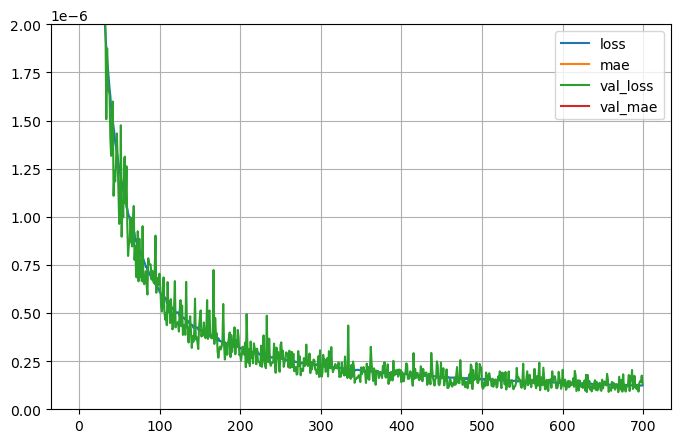

✅ Modelo LSTM listo para usar.


In [15]:
# Verificar si el modelo ya existe

LSTM_model_path = "2LPR_LSTM_nn_Best_Model.h5"
LSTM_history_path = "2LPR_lstm_best_history.json"

if os.path.exists(LSTM_model_path):
    print("🔄 Cargando modelo LSTM existente...")
    LSTM_network = keras.models.load_model(LSTM_model_path)
    LSTM_network.summary()

    if os.path.exists(LSTM_history_path):

        with open(LSTM_history_path, "r") as f:
            LSTM_history = json.load(f)  # Load the history data as a dictionary
        # Create a dummy History object for plotting:
        #LSTM_history = type('DummyHistory', (object,), {'history': LSTM_history_dict})()

        # Graficar el history
        plt.figure(figsize=(8, 5))
        plt.plot(LSTM_history["loss"], label="Training Loss")
        plt.plot(LSTM_history["val_loss"], label="Validation Loss")
        plt.legend()
        plt.xlabel("Épocas")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.gca().set_ylim(0, 2e-6)
        plt.title("Historial de entrenamiento del modelo LSTM")
        plt.show()
    else:
        print("⚠️ No se encontró el archivo de history.")
else:
    print("⚙️ Creando nuevo modelo...")
    LSTM_network = Sequential() #Sequential([Input(shape=(w_size, X_train_LSTM.shape[2]))])
    LSTM_network.add(LSTM(30, activation='tanh', input_shape=(w_size, X_train_LSTM.shape[2])))
    
    #LSTM_network.add(LSTM(10, activation='tanh', input_shape=(w_size, X_train_LSTM.shape[2]), 
    #                return_sequences=True))
    #LSTM_network.add(LSTM(2, activation='tanh',
    #                return_sequences=True, kernel_regularizer=l2(0)))
    #LSTM_network.add(LSTM(10, activation='tanh'))
    LSTM_network.add(Dense(y_train_LSTM.shape[1]))
    LSTM_network.compile(loss = 'mean_squared_error', optimizer=keras.optimizers.Adam(1e-4), metrics = ['mae']) #learning_rate=1e-5
    #mean_sqared_error
    LSTM_network.summary()


    #LSTM_checkpoint_cb = keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/CT_p/Modelos_NN/LINEAR/LSTM_nn_Best_Model.h5", save_best_only=True)
    LSTM_checkpoint_cb = keras.callbacks.ModelCheckpoint(LSTM_model_path,save_best_only=True)
    LSTM_early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                           patience=50, min_delta=1E-10, 
                                                           restore_best_weights=True)

    LSTM_history = LSTM_network.fit(X_train_LSTM, y_train_LSTM, epochs=700, 
                                    batch_size=128, validation_data=(X_val_LSTM, y_val_LSTM), 
                                    callbacks=[LSTM_checkpoint_cb, LSTM_early_stopping_cb])
    
    with open(LSTM_history_path, "w") as f:
        json.dump(LSTM_history.history, f)
    with open(LSTM_history_path, "r") as f:
        LSTM_history = json.load(f)  # Load the history data as a dictionary

    # Create a dummy History object for plotting:
    #LSTM_history = type('DummyHistory', (object,), {'history': LSTM_history_dict})()

    pd.DataFrame(LSTM_history).plot(figsize=(8, 5))
    plt.grid(True)
    #plt.gca().set_xlim(0, 1)
    plt.gca().set_ylim(0, 2e-6)
    plt.show()

print("✅ Modelo LSTM listo para usar.")

In [16]:
!ls -lh 2LPR_LSTM_nn_Best_Model.h5 2LPR_lstm_best_history.json


-rw-rw---- 1 wsuser wscommon 65K Jul 16 17:00 2LPR_lstm_best_history.json
-rw-rw---- 1 wsuser wscommon 80K Jul 16 16:48 2LPR_LSTM_nn_Best_Model.h5


In [ ]:
from IPython.display import FileLink

# Crear enlaces para descarga
FileLink('2LPR_LSTM_nn_Best_Model.h5')

/home/wsuser/work/2LPR_LSTM_nn_Best_Model.h5

In [ ]:
FileLink('2LPR_lstm_best_history.json')

/home/wsuser/work/2LPR_lstm_best_history.json

In [ ]:
#import os
#os.remove("2LPR_LSTM_nn_Best_Model.h5")
#os.remove("2LPR_lstm_best_history.json")

In [ ]:
LSTM_accuracy_test = LSTM_network.evaluate(X_test_LSTM, y_test_LSTM)

2351/2351 [==============================] - 12s 5ms/step - loss: 1.4165e-07 - mae: 2.5948e-04


In [ ]:
predictions_LSTM = LSTM_network.predict(X_test_LSTM)

2351/2351 [==============================] - 10s 4ms/step


In [ ]:
predictions_LSTM[0]

array([0.23388359, 0.38079876], dtype=float32)

In [ ]:
y_test_LSTM[0]

array([0.23403532, 0.38074679])

# **Verificación con otro conjunto de datos**

In [ ]:
#Uso el otro dataset joint
datos_2LRP_ref_joint = df_1 #pd.read_csv(f'./2lpr_jointmovement_2025_07_10-13_45_12.csv',delimiter=',', encoding="utf-8", skipinitialspace=True)
#datos_2LRP_ref_joint = pd.read_csv(f'./2lpr_noise_jointmovement_2025_06_23-09_59_59.csv', delimiter=',', encoding="utf-8", skipinitialspace=True)

#datos_2LRP_ref_joint.head()
t_ref = datos_2LRP_ref_joint.iloc[1:-1,1].values

q1_ref = datos_2LRP_ref_joint.iloc[:-2,2].values
q2_ref = datos_2LRP_ref_joint.iloc[:-2,3].values

dq1_ref = datos_2LRP_ref_joint.iloc[:-2,4].values
dq2_ref = datos_2LRP_ref_joint.iloc[:-2,5].values

ddq1_ref = datos_2LRP_ref_joint.iloc[1:-1,6].values
ddq2_ref = datos_2LRP_ref_joint.iloc[1:-1,7].values

t1_ref = datos_2LRP_ref_joint.iloc[1:-1,8].values
t2_ref = datos_2LRP_ref_joint.iloc[1:-1,9].values

next_q1_ref = datos_2LRP_ref_joint.iloc[1:-1,2].values
next_q2_ref = datos_2LRP_ref_joint.iloc[1:-1,3].values

datos_2LRP_ref_joint.head()

,ID,Time,Theta_1,Theta_2,D_Theta_1,D_Theta_2,DD_Theta_1,DD_Theta_2,Torque_1,Torque_2
0,1,0.000000,2.586658,-2.671982,-0.210963,0.039151,-21.096266,3.915107,-2.732169,1.182864
1,2,0.010000,2.583494,-2.671395,-0.421925,0.078302,-21.096266,3.915107,-2.832746,1.200899
2,3,0.020000,2.578220,-2.670416,-0.632888,0.117453,-21.096266,3.915107,-2.930007,1.217885
3,4,0.030001,2.570836,-2.669046,-0.843851,0.156604,-21.096266,3.915107,-3.023879,1.233792
4,5,0.040001,2.561343,-2.667284,-1.054813,0.195755,-21.096266,3.915107,-3.114265,1.248576


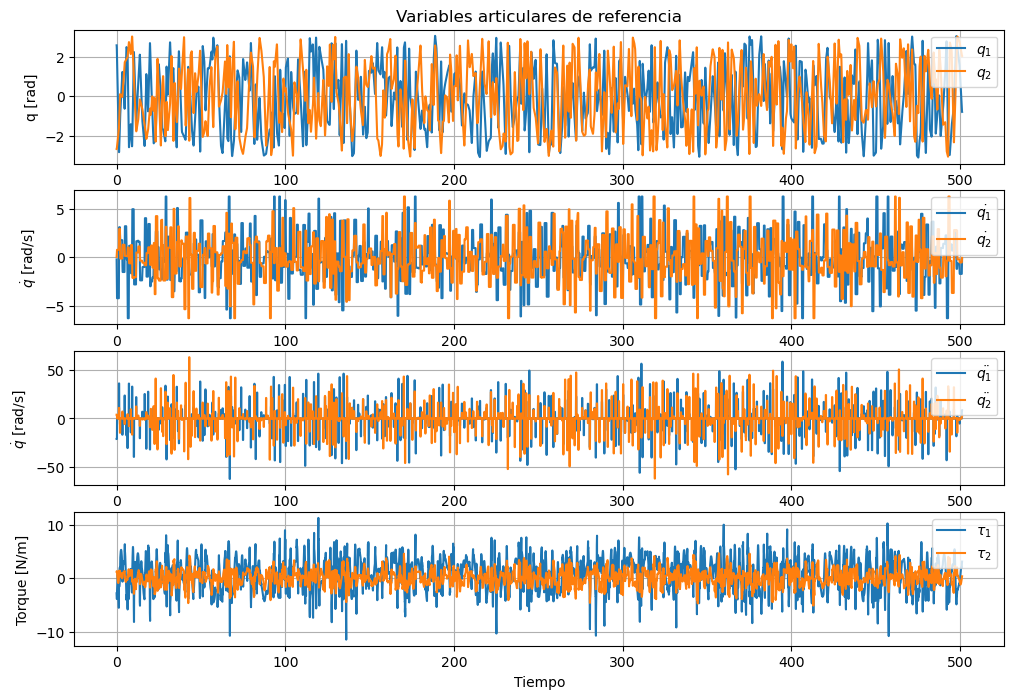

In [ ]:
num_links = 2

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades
plt.subplot(4,1,1)
plt.plot(t_ref, q1_ref)
plt.plot(t_ref, q2_ref)
plt.legend([r'$q_1$', r'$q_2$'],loc='upper right', fontsize=10);  plt.ylabel(r'q [rad]')
plt.grid(True)
plt.title('Variables articulares de referencia')
plt.subplot(4,1,2)
plt.plot(t_ref, dq1_ref)
plt.plot(t_ref, dq2_ref)
plt.legend([r'$\dot{q_{1}}$', r'$\dot{q_{2}}$'],loc='upper right', fontsize=10);  plt.ylabel(r'$\dot{q}$ [rad/s]')
plt.grid(True)
plt.subplot(4,1,3)
plt.plot(t_ref, ddq1_ref)
plt.plot(t_ref, ddq2_ref)
plt.legend([r'$\ddot{q_{1}}$', r'$\ddot{q_{2}}$'],loc='upper right', fontsize=10);  plt.ylabel(r'$\dot{q}$ [rad/s]')
plt.grid(True)
plt.subplot(4,1,4)
plt.plot(t_ref, t1_ref)
plt.plot(t_ref, t2_ref)
plt.legend([r'$\tau_{1}$', r'$\tau_{2}$'],loc='upper right', fontsize=10); plt.xlabel('Tiempo'); plt.ylabel('Torque [N/m]')
plt.grid(True)
plt.show()


In [ ]:
inputs_ref = np.vstack((q1_ref,q2_ref,t1_ref,t2_ref)).T
inputs_ref_LSTM = np.vstack((q1_ref,q2_ref,t1_ref,t2_ref)).T
outputs_ref = np.vstack((next_q1_ref,next_q2_ref)).T

In [ ]:
def create_sequences_with_time(data, time, window_size= w_size):
    sequences = []
    times = []
    
    for i in range(len(data) - window_size):
        sequence = data[i:i + window_size]
        sequences.append(sequence)
        
        # Alinear con el tiempo del último dato de la ventana
        time_point = time[i + window_size - 1]
        times.append(time_point)
    
    return np.array(sequences), np.array(times)

w_size = 50
X_test_scaled_LSTM = scaler1_LSTM.transform(inputs_ref_LSTM)
X_test_windowed_LSTM, t_ref_LSTM = create_sequences_with_time(X_test_scaled_LSTM, t_ref)
q_sim_LSTM = scaler2_LSTM.inverse_transform(LSTM_network.predict(X_test_windowed_LSTM))

1566/1566 [==============================] - 6s 4ms/step


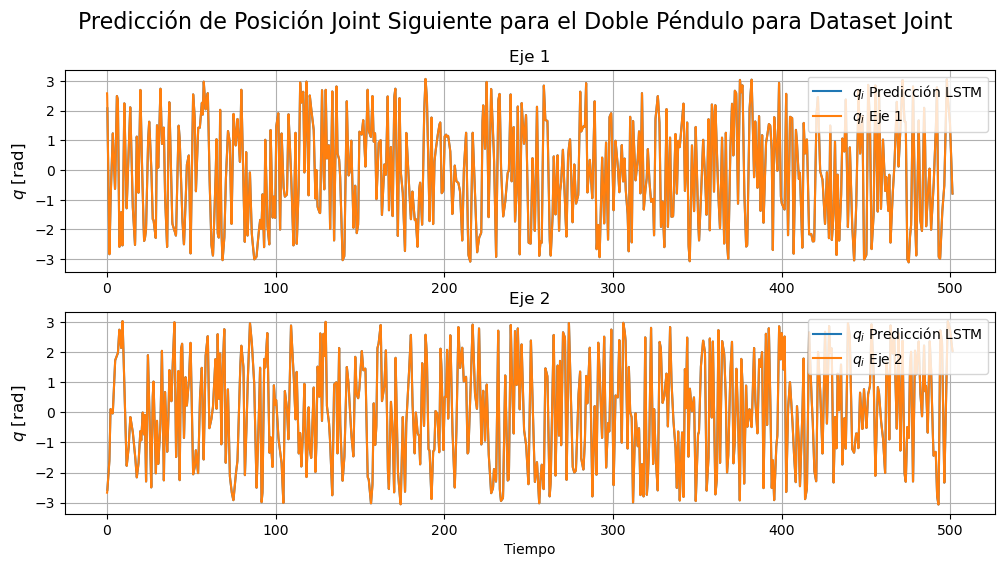

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 6))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Predicción de Posición Joint Siguiente para el Doble Péndulo para Dataset Joint", fontsize=16, y=0.95)

# Grafico los resultados
for i in range(num_links):
  plt.subplot(num_links, 1, i+1)
  #plt.plot(t_ref,q_sim_FF_NN[:,i])
  plt.plot(t_ref_LSTM,q_sim_LSTM[:,i])
  plt.plot(t_ref,outputs_ref[:,i])
  plt.ylabel(r'$q$ [rad]', fontsize=12)
  plt.legend([r"$q_{i}$ Predicción LSTM", r"$q_{i}$ " f'Eje {i+1}'],loc='upper right', 
             fontsize=10)
  #plt.gca().set_xlim(0, 0.1)
  #plt.gca().set_ylim(-1.45, -1.4)
  plt.title(f'Eje {i+1}', fontsize=12)
  plt.grid(True)

plt.subplots_adjust(top=0.85)  
plt.xlabel('Tiempo');
plt.show()


ValueError: operands could not be broadcast together with shapes (50110,) (50080,) 

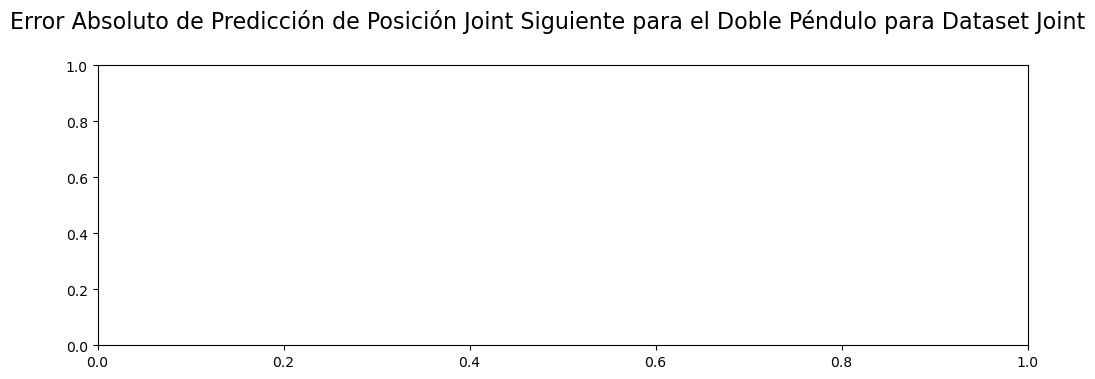

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Error Absoluto de Predicción de Posición Joint Siguiente para el Doble Péndulo para Dataset Joint", 
             fontsize=16,  y=0.95)

# Graficar los errores
for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)

    #error_OSA_Joint_j = np.sqrt((q_sim_FF_NN[:, i] - outputs_ref[:, i])**2)
    #error_LSTM_Joint_j = np.sqrt((q_sim_LSTM[:-1, i] - outputs_ref[w_size:, i])**2)
    # Cálculo del error absoluto
    error_LSTM_Joint_j = np.abs(q_sim_LSTM[:, i] - outputs_ref[w_size:, i])
    #error_OSA_Joint_j = np.abs(q_sim_FF_NN[:, i] - outputs_ref[:, i])

    #print(max(error_OSA_Joint_j))
    print(max(error_LSTM_Joint_j))
    
    # Graficar los errores
    #plt.plot(t_ref, error_OSA_Joint_j, label='Error SS Joint')
    #plt.plot(t_ref_LSTM[:], error_LSTM_Joint_j, label='Error LSTM Joint')    
    #plt.plot(t_ref[:], error_OSA_Joint_j, label='Error FF', alpha=0.8)
    plt.plot(t_ref[w_size:], error_LSTM_Joint_j, label='Error LSTM', alpha=0.8)
    
    # Ajustar etiquetas y título del subplot
    plt.ylabel(r'Error [rad]', fontsize=12)
    plt.title(f'Eje {i+1}', fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

plt.subplots_adjust(top=0.85)  

# Ajustar los espacios entre subplots
#plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()



# **Reconstrucción de las señales (Velocidad y Aceleración)**

A partir de las estimaciones encontradas, creo una función que pueda llamar y guardar las estimaciones, como también las velocidades y aceleraciones reconstuidas.

In [ ]:
q_sim_LSTM.shape

In [ ]:
q_ref = np.vstack((q1_ref, q2_ref)).T  # Forzar matriz válida
dq_ref = np.vstack((dq1_ref, dq2_ref)).T  # Forzar matriz válida
ddq_ref = np.vstack((ddq1_ref, ddq2_ref)).T  # Forzar matriz válida
tau_ref = np.vstack((t1_ref, t2_ref)).T 
dq_ref[:,1]

In [ ]:
def reconstruir_dinamica(t, q_est, metodo="diferencias", sigma_1=10, sigma_2=10):
    """
    Reconstruye la velocidad y la aceleración a partir de posiciones estimadas y el vector de tiempo.
    
    Parámetros:
        t (numpy array): Vector de tiempo.
        q_est (numpy array): Posiciones estimadas.
        metodo (str): Método a utilizar ("diferencias", "savgol", "spline").
        window_length (int): Tamaño de la ventana para Savitzky-Golay (debe ser impar).
        polyorder (int): Orden del polinomio para Savitzky-Golay.
        h (float): Paso de tiempo si no se proporciona `t`.
        spline_smooth (float): Parámetro de suavizado para el spline (mayor valor = más suavizado).
        
    Retorna:
        qd_est (numpy array): Velocidad estimada.
        qdd_est (numpy array): Aceleración estimada.
    """
  
    # Convertir a arreglos de NumPy
    t = np.asarray(t)
    q_est = np.asarray(q_est)

    # Verificar que t y q_est tengan la misma longitud
    if len(t) != len(q_est):
        raise ValueError("Los vectores t y q_est deben tener la misma longitud.")

    if metodo == "diferencias":
        qd_est = np.gradient(q_est, t, axis=0)  
        qd_est = np.array([gaussian_filter1d(qd_est[:, i], sigma_1) for i in range(qd_est.shape[1])]).T
        qdd_est = np.gradient(qd_est, t, axis=0)
        qdd_est = np.array([gaussian_filter1d(qdd_est[:, i], sigma_2) for i in range(qdd_est.shape[1])]).T

    elif metodo == "spline":
        # Crear un spline cúbico con suavizado
        #spline = CubicSpline(t, q_est, bc_type='natural')
        qd_est = CubicSpline(t, q_est, bc_type='natural').derivative()(t)
        qd_est = np.array([gaussian_filter1d(qd_est[:, i], sigma_1) for i in range(qd_est.shape[1])]).T
        qdd_est = CubicSpline(t, qd_est).derivative(1)(t)
        qd_est = np.array([gaussian_filter1d(qd_est[:, i], sigma_2) for i in range(qd_est.shape[1])]).T



    else:
        raise ValueError("Método no reconocido. Use 'diferencias' o 'spline'.")

    return qd_est, qdd_est


In [ ]:
qd_spline_2, qdd_spline_2 = reconstruir_dinamica(t_ref_LSTM, q_sim_LSTM, metodo="spline", sigma_1=10, sigma_2=5)
qd_diff_2, qdd_diff_2 = reconstruir_dinamica(t_ref_LSTM, q_sim_LSTM, metodo="diferencias", sigma_1=10, sigma_2=5)

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Comparación de Velocidades reconstruidas", fontsize=16)

for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)

    # Velocidad - Comparación spline vs diferencias
    plt.plot(t_ref, dq_ref[:,i], label="Original", linewidth=4)
    plt.plot(t_ref_LSTM, qd_spline_2[:,i], label="Spline", linewidth=2)
    plt.plot(t_ref_LSTM[:], qd_diff_2[:,i], linestyle="dashed", label="Diferencias", alpha=0.7)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Velocidad (rad/s)")
    plt.title(f'Velocidad Eje {i+1}', fontsize=14)
    plt.legend()
    plt.ylim
    plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Comparación de Aceleraciones reconstruidas", fontsize=16)

for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)


# Aceleración - Comparación spline vs diferencias
    plt.plot(t_ref, ddq_ref[:,i], label="Original", linewidth=4)
    plt.plot(t_ref_LSTM, qdd_spline_2[:,i], label="Spline", linewidth=2)
    plt.plot(t_ref_LSTM[:], qdd_diff_2[:,i], linestyle="dashed", label="Diferencias", alpha=0.7)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Aceleración (rad/s²)")
    plt.title(f'Aceleración Eje {i+1}', fontsize=14)
    plt.legend()
    plt.grid()


plt.tight_layout()
plt.show()

In [ ]:
def write_noise_data_to_csv(file_name, t_ref, q_ref, qd_ref, qdd_ref, tau_ref, q_ref_noise, qd_ref_noise, qdd_ref_noise):
    fecha_actual = datetime.now().strftime('%Y_%m_%d-%H_%M_%S')
    directory = './2LPR/DD_NN_Pos_1E2/DATA/'
    filename = f'{directory}{file_name}_{fecha_actual}.csv'

    # Crear el directorio si no existe
    os.makedirs(directory, exist_ok=True)

    cantidad = len(t_ref)

    if not os.path.isfile(filename) or os.path.getsize(filename) == 0:
        # Si el archivo no existe o está vacío, escribir las cabeceras CSV
        with open(filename, 'w') as archivo:
            archivo.write('ID, Time, Theta_1, Theta_2, D_Theta_1, D_Theta_2, DD_Theta_1, DD_Theta_2, Torque_1, Torque_2, Theta_N_1, Theta_N_2, D_Theta_N_1, D_Theta_N_2, DD_Theta_N_1, DD_Theta_N_2\n')
    with open(filename, 'a') as archivo:
        for _ in range(cantidad):
            id = _ +1
            time = t_ref[_]
            j_1 = q_ref[_][0]
            j_2 = q_ref[_][1]
            d_j_1 = qd_ref[_][0]
            d_j_2 = qd_ref[_][1]
            dd_j_1 = qdd_ref[_][0]
            dd_j_2 = qdd_ref[_][1]
            tau_1 = tau_ref[_][0]
            tau_2 = tau_ref[_][1]
            j_1_noise = q_ref_noise[_][0]
            j_2_noise = q_ref_noise[_][1]
            d_j_1_noise = qd_ref_noise[_][0]
            d_j_2_noise = qd_ref_noise[_][1]
            dd_j_1_noise = qdd_ref_noise[_][0]
            dd_j_2_noise = qdd_ref_noise[_][1]

            archivo.write(f'{id}, {time}, {j_1}, {j_2}, {d_j_1}, {d_j_2}, {dd_j_1}, {dd_j_2}, {tau_1}, {tau_2}, {j_1_noise}, {j_2_noise}, {d_j_1_noise}, {d_j_2_noise}, {dd_j_1_noise}, {dd_j_2_noise}\n')

In [ ]:
#q_ref = np.vstack((q1_ref, q2_ref)).T  
#dq_ref = np.vstack((dq1_ref, dq2_ref)).T  
#ddq_ref = np.vstack((ddq1_ref, ddq2_ref)).T  
tau_ref = np.vstack((t1_ref, t2_ref)).T 

file_name = 'Reconstruccion_2lpr_jointmovement'
#write_noise_data_to_csv(file_name, t_ref_LSTM, q_ref, dq_ref, ddq_ref, tau_ref, q_sim_LSTM, qd_spline_2, qdd_spline_2)

# **Comparación de conjunto de Datos, Cartesiano vs Joint**

Para la comparación entre el conjunto de datos Cartesiano vs Joint, voy a crear otras redes neuronales FF y LSTM con las mismas características que las anteriores, entrenándolas exclusivamente con datasets cartesianos, y se compara la estimación de las 4 redes utilizando un nuevo conjunto joint y un nuevo conjunto cartesiano.

In [ ]:
#Inputs ---> uk=[qTk-1  d_qTk-1  tauTk]T
time_cart = datos_2LRP_cart.iloc[1:-1,1].values

pos_j1_cart = datos_2LRP_cart.iloc[:-2,2].values
pos_j2_cart = datos_2LRP_cart.iloc[:-2,3].values

vels_j1_cart = datos_2LRP_cart.iloc[:-2,4].values
vels_j2_cart = datos_2LRP_cart.iloc[:-2,5].values

accs_j1_cart = datos_2LRP_cart.iloc[1:-1,6].values
accs_j2_cart = datos_2LRP_cart.iloc[1:-1,7].values

torq_j1_cart = datos_2LRP_cart.iloc[1:-1,8].values
torq_j2_cart = datos_2LRP_cart.iloc[1:-1,9].values

next_pos_j1_cart = datos_2LRP_cart.iloc[1:-1,2].values
next_pos_j2_cart = datos_2LRP_cart.iloc[1:-1,3].values

# Comparación de estimaciones

**Estimación de Dataset Cartesiano**

In [ ]:
#Estimación de Dataset Cartesiano

datos_2LRP_comp_cart = pd.read_csv(f'./2lpr_cartesianmovement_2025_07_10-13_45_12.csv',delimiter=',', encoding="utf-8", skipinitialspace=True)

t_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,1].values

q1_ref_comp_cart = datos_2LRP_comp_cart.iloc[:-2,2].values
q2_ref_comp_cart = datos_2LRP_comp_cart.iloc[:-2,3].values

dq1_ref_comp_cart = datos_2LRP_comp_cart.iloc[:-2,4].values
dq2_ref_comp_cart = datos_2LRP_comp_cart.iloc[:-2,5].values

ddq1_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,6].values
ddq2_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,7].values

t1_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,8].values
t2_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,9].values

next_q1_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,2].values
next_q2_ref_comp_cart = datos_2LRP_comp_cart.iloc[1:-1,3].values

datos_2LRP_comp_cart.head()

In [ ]:
num_links = 2

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades
plt.subplot(4,1,1)
plt.plot(t_ref_comp_cart, q1_ref_comp_cart)
plt.plot(t_ref_comp_cart, q2_ref_comp_cart)
plt.legend([r'$q_1$', r'$q_2$'],loc='upper right', fontsize=10);  plt.ylabel(r"$q$ [rad]")
plt.grid(True)
plt.title('Variables articulares de referencia (Movimiento Cartesiano)')
plt.subplot(4,1,2)
plt.plot(t_ref_comp_cart, dq1_ref_comp_cart)
plt.plot(t_ref_comp_cart, dq2_ref_comp_cart)
plt.legend([r'$\dot{q_1}$', r'$\dot{q_2}$'],loc='upper right', fontsize=10);  plt.ylabel(r"$\dot{q}$ [rad/s]")
plt.grid(True)
plt.subplot(4,1,3)
plt.plot(t_ref_comp_cart, ddq1_ref_comp_cart)
plt.plot(t_ref_comp_cart, ddq2_ref_comp_cart)
plt.legend([r'$\ddot{q_1}$', r'$\ddot{q_2}$'],loc='upper right', fontsize=10); plt.ylabel(r"$\ddot{q}$ [rad/s²]")
plt.grid(True)
plt.subplot(4,1,4)
plt.plot(t_ref_comp_cart, t1_ref_comp_cart)
plt.plot(t_ref_comp_cart, t2_ref_comp_cart)
plt.legend([r'$\tau_{1}$', r'$\tau_{2}$'],loc='upper right', fontsize=10); plt.xlabel('Tiempo'); plt.ylabel('Torque [N/m]')
plt.grid(True)
plt.show()

In [ ]:
inputs_ref_comp_cart = np.vstack((q1_ref_comp_cart,q2_ref_comp_cart,t1_ref_comp_cart,t2_ref_comp_cart)).T
inputs_ref_comp_cart_LSTM = np.vstack((q1_ref_comp_cart,q2_ref_comp_cart,t1_ref_comp_cart,t2_ref_comp_cart)).T
outputs_ref_comp_cart = np.vstack((next_q1_ref_comp_cart,next_q2_ref_comp_cart)).T

In [ ]:
#Con LSTM entrenada con Joint
X_test_scaled_LSTM_comp_cart_j = scaler1_LSTM.transform(inputs_ref_comp_cart_LSTM)
X_test_windowed_LSTM_comp_cart_j, t_ref_LSTM_comp_cart_j = create_sequences_with_time(X_test_scaled_LSTM_comp_cart_j, t_ref_comp_cart)
X_test_windowed_LSTM_comp_cart_j
next_qs_sim_LSTM_comp_cart_j = scaler2_LSTM.inverse_transform(LSTM_network.predict(X_test_windowed_LSTM_comp_cart_j))

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Predicción de Posición Joint Siguiente para el Doble Péndulo para Dataset Cartesiano", fontsize=16)

# Graficar los resultados
for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)
    
    # Graficar las diferentes predicciones y los valores reales
    plt.plot(t_ref_LSTM_comp_cart_j, next_qs_sim_LSTM_comp_cart_j[:, i], label='Predicción LSTM Joint')
    plt.plot(t_ref_comp_cart, outputs_ref_comp_cart[:, i], label=f'Eje {i+1}')
    
    # Ajustar etiquetas y título del subplot
    plt.ylabel(r'$q$ [rad]', fontsize=12)
    plt.title(f'Eje {i+1}', fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

# Ajustar los espacios entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()


In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Error de Predicción de Posición Joint Siguente para el Doble Péndulo para Dataset Cartesiano", fontsize=16)

# Graficar los errores
for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)
    
   
    error_LSTM_Joint_c = np.sqrt((next_qs_sim_LSTM_comp_cart_j[:, i] - outputs_ref_comp_cart[w_size:, i])**2)

    #print(max(error_OSA_Cart_c))
    #print(max(error_OSA_Joint_c))
    #print(max(error_LSTM_Cart_c))
    #print(max(error_LSTM_Joint_c))
    print(np.mean(error_LSTM_Joint_c))

    # Graficar los errores
    #plt.plot(t_ref_comp_cart, error_OSA_Cart_c, label='Error FF Cart')
    #plt.plot(t_ref_comp_cart[w_size:], error_LSTM_Cart_c, label='Error LSTM Cart')
    plt.plot(t_ref_comp_cart[w_size:], error_LSTM_Joint_c, label='Error LSTM Joint')
    
    # Ajustar etiquetas y título del subplot
    plt.ylabel('Error [rad]', fontsize=12)
    plt.title(f'Eje {i+1}', fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

# Ajustar los espacios entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()


# **Análisis de Ruido**

Para las redes entrenadas con Joint, LSTM y FF, analizo la respuesta a ruido blanco gaussiano en la posición.

In [ ]:
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025-02-18.csv',delimiter=',', encoding="utf-8", skipinitialspace=True)
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025-05-09.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-8
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025-05-14.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-6
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025_05_14-07_59_27.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-4
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025_05_14-08_05_05.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-3


#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025_07_07-23_19_19.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-8
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025_07_07-23_19_34.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-6
#datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025_07_07-23_21_40.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-4
datos_2LRP_comp_joint_noise = pd.read_csv(f'./2lpr_noise_jointmovement_2025_07_07-23_15_03.csv',delimiter=',', encoding="utf-8", skipinitialspace=True) #pos_noise_std=1e-3


std_level="1e-3"

t_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,1].values

q1_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,2].values
q2_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,3].values

next_q1_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,2].values
next_q2_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,3].values

dq1_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,4].values
dq2_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,5].values

ddq1_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,6].values
ddq2_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,7].values

t1_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,8].values
t2_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,9].values

next_q1_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,2].values
next_q2_ref_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,3].values

q1_noise_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,10].values
q2_noise_comp_joint = datos_2LRP_comp_joint_noise.iloc[:-2,11].values

next_q1_noise_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,10].values
next_q2_noise_comp_joint = datos_2LRP_comp_joint_noise.iloc[1:-1,11].values
datos_2LRP_comp_joint_noise.head()

In [ ]:
tau_ref_comp_joint = np.vstack((t1_ref_comp_joint,t2_ref_comp_joint)).T
dq_ref_comp_joint = np.vstack((dq1_ref_comp_joint,dq2_ref_comp_joint)).T
ddq_ref_comp_joint = np.vstack((ddq1_ref_comp_joint,ddq2_ref_comp_joint)).T
w_size = 50

In [ ]:
num_links = 2

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))  # Cambia el tamaño según tus necesidades
plt.subplot(4,1,1)
plt.plot(t_ref_comp_joint, q1_ref_comp_joint)
plt.plot(t_ref_comp_joint, q2_ref_comp_joint)
plt.plot(t_ref_comp_joint, q1_noise_comp_joint)
plt.plot(t_ref_comp_joint, q2_noise_comp_joint)
plt.legend([r'$q_1$', r'$q_2$', r'$q_{1_{noise}}$', r'$q_{2_{noise}}$'],loc='upper right', fontsize=10);  plt.ylabel('q [rad]')
plt.grid(True)
plt.title('Variables articulares de referencia con ruido en la posición (Movimiento Joint)')
plt.subplot(4,1,2)
plt.plot(t_ref_comp_joint, dq1_ref_comp_joint)
plt.plot(t_ref_comp_joint, dq2_ref_comp_joint)
plt.legend([r'$\dot{q}_1$', r'$\dot{q}_2$'],loc='upper right', fontsize=10);  plt.ylabel(r'$\dot{q}$ [rad/s]')
plt.grid(True)
plt.subplot(4,1,3)
plt.plot(t_ref_comp_joint, ddq1_ref_comp_joint)
plt.plot(t_ref_comp_joint, ddq2_ref_comp_joint)
plt.legend([r'$\ddot{q}_1$', r'$\ddot{q}_2$'],loc='upper right', fontsize=10);  plt.ylabel(r'$\ddot{q}$ [rad/s²]'); 
plt.grid(True)
plt.subplot(4,1,4)
plt.plot(t_ref_comp_joint, t1_ref_comp_joint)
plt.plot(t_ref_comp_joint, t2_ref_comp_joint)
plt.legend([r'$\tau_{1}$', r'$\tau_{2}$'],loc='upper right', fontsize=10); plt.xlabel('Tiempo'); plt.ylabel('Torque [N/m]')
plt.grid(True)
plt.show()

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 6))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.title("Diferencia entre Señal Ideal vs Ruidosa", fontsize=16)


noise_q1 =(q1_ref_comp_joint - q1_noise_comp_joint)
noise_q2 = (q2_ref_comp_joint - q2_noise_comp_joint)
noise = np.vstack((noise_q1, noise_q2)).T  # Ahora noise.shape == (N, 2)

# Graficar los errores
plt.plot(t_ref_comp_joint, noise_q1, label=f'Ruido $q_1$')
plt.plot(t_ref_comp_joint, noise_q2, label=f'Ruido $q_2$')


# Ajustar etiquetas y título del subplot
plt.ylabel('Error [rad]', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

# Ajustar los espacios entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()

In [ ]:
inputs_noise_comp_joint = np.vstack((q1_noise_comp_joint,q2_noise_comp_joint,t1_ref_comp_joint,t2_ref_comp_joint)).T
outputs_noise_comp_joint = np.vstack((next_q1_noise_comp_joint,next_q2_noise_comp_joint)).T
outputs_noise_comp_joint_2 = np.vstack((next_q1_ref_comp_joint,next_q2_ref_comp_joint)).T

In [ ]:
#Primero con FF NN

X_noise_scaled_FF_NN = scaler1_OSA.transform(inputs_noise_comp_joint)
q_noise_FF_NN = scaler2_OSA.inverse_transform(FF_NN_network.predict(X_noise_scaled_FF_NN))

In [ ]:
X_noise_scaled_LSTM = scaler1_LSTM.transform(inputs_noise_comp_joint)
X_noise_windowed_LSTM, t_noise_LSTM = create_sequences_with_time(X_noise_scaled_LSTM, t_ref_comp_joint)
q_noise_LSTM = scaler2_LSTM.inverse_transform(LSTM_network.predict(X_noise_windowed_LSTM))

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 12))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Predicción de Posición para el Doble Péndulo con Ruido", fontsize=16)

# Grafico los resultados
for i in range(num_links):
  plt.subplot(num_links, 1, i+1)
  plt.plot(t_ref_comp_joint,q_noise_FF_NN[:,i])
  plt.plot(t_noise_LSTM,q_noise_LSTM[:,i])
  plt.plot(t_ref_comp_joint,outputs_noise_comp_joint[:,i])
  plt.plot(t_ref_comp_joint,outputs_noise_comp_joint_2[:,i])
  plt.ylabel(r'$q$ [rad]', fontsize=12)
  plt.legend(['Predicción FF', 'Predicción LSTM', f'Eje {i+1}', f'Eje {i+1} Ideal'],loc='upper right', fontsize=10)
  plt.title(f'Eje {i+1}', fontsize=14)
  plt.grid(True)

# Ajustar los espacios entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.98])  # Dejar espacio para el título general
plt.xlabel('Tiempo');
plt.show()

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 12))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Error de Predicción de Posición Joint Siguiente para el Doble Péndulo para Dataset Joint con ruido", fontsize=16)

# Graficar los errores
for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)

    error_OSA_Joint_j_noise = np.sqrt((q_noise_FF_NN[:, i] - outputs_noise_comp_joint[:, i])**2)
    error_LSTM_Joint_j_noise = np.sqrt((q_noise_LSTM[:, i] - outputs_noise_comp_joint[w_size:, i])**2)
    error_OSA_Joint_j_noise_2 = np.sqrt((q_noise_FF_NN[:, i] - outputs_noise_comp_joint_2[:, i])**2)
    error_LSTM_Joint_j_noise_2 = np.sqrt((q_noise_LSTM[:, i] - outputs_noise_comp_joint_2[w_size:, i])**2)
    # Para eje i (por ejemplo, eje 0 o 1)
    y_true = outputs_noise_comp_joint[:, i]             # Señal real con ruido
    y_pred_ff = q_noise_FF_NN[:, i]                     # Predicción FF
    y_pred_lstm = q_noise_LSTM[:, i]                    # Predicción LSTM

    # MAE
    mae_ff = mean_absolute_error(y_true, y_pred_ff)
    mae_lstm = mean_absolute_error(y_true[w_size:], y_pred_lstm)

    # MSE
    mse_ff = mean_squared_error(y_true, y_pred_ff)
    mse_lstm = mean_squared_error(y_true[w_size:], y_pred_lstm)

    # R²
    r2_ff = r2_score(y_true, y_pred_ff)
    r2_lstm = r2_score(y_true[w_size:], y_pred_lstm)

    # Imprimir resultados
    print(f"Eje {i+1}:")
    print(f"FF - MAE: {mae_ff:.6e}, MSE: {mse_ff:.6e}, R²: {r2_ff:.10f}")
    print(f"LSTM - MAE: {mae_lstm:.6e}, MSE: {mse_lstm:.6e}, R²: {r2_lstm:.10f}")

    #error_OSA_Joint_j_noise = (q_noise_FF_NN[:, i] - outputs_noise_comp_joint[:, i])
    #error_LSTM_Joint_j_noise = (q_noise_LSTM[:, i] - outputs_noise_comp_joint[w_size:, i])
    #error_OSA_Joint_j_noise_2 = (q_noise_FF_NN[:, i] - outputs_noise_comp_joint_2[:, i])
    #error_LSTM_Joint_j_noise_2 = (q_noise_LSTM[:, i] - outputs_noise_comp_joint_2[w_size:, i])
    
    
    # Graficar los errores
    plt.plot(t_ref_comp_joint, error_OSA_Joint_j_noise, label='Error FF Joint vs Ruido')
    plt.plot(t_ref_comp_joint[w_size:], error_LSTM_Joint_j_noise, label='Error LSTM Joint vs Ruido')
    plt.plot(t_ref_comp_joint, error_OSA_Joint_j_noise_2, label='Error FF Joint vs Ideal')
    plt.plot(t_ref_comp_joint[w_size:], error_LSTM_Joint_j_noise_2, label='Error LSTM Joint vs Ideal')
    #plt.plot(t_ref_comp_joint, noise[:,i], label='Ruido')

    
    # Ajustar etiquetas y título del subplot
    plt.ylabel('Error [rad]', fontsize=12)
    plt.title(f'Eje {i+1}', fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

# Ajustar los espacios entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.98])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()

**Tengo que calcular veociades y aceleraciones en base a las muestras ruidosas**

In [ ]:
#qd_noise_spline, qdd_noise_spline = reconstruir_dinamica(t_noise_LSTM, q_noise_LSTM, metodo="spline",sigma_1=6, sigma_2=2)
qd_noise_diff, qdd_noise_diff = reconstruir_dinamica(t_noise_LSTM, q_noise_LSTM, metodo="diferencias",sigma_1=6, sigma_2=4)

In [ ]:
5e-2

In [ ]:
t_ref_comp_joint[49]

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 12))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Comparación de Velocidades reconstruidas", fontsize=16)

for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)


# Aceleración - Comparación spline vs diferencias
    plt.plot(t_ref_comp_joint, dq_ref_comp_joint[:,i], label="Original", linewidth=4)
    #plt.plot(t_noise_LSTM, qd_noise_spline[:,i], label="Spline", linewidth=2)
    plt.plot(t_noise_LSTM[:], qd_noise_diff[:,i], label="Diferencias", linewidth=2)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Velocidad (rad/s)")
    plt.title(f'Velocidad Eje {i+1}', fontsize=14)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 12))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Comparación de Aceleraciones reconstruidas", fontsize=16)

for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)


# Aceleración - Comparación spline vs diferencias
    plt.plot(t_ref_comp_joint, ddq_ref_comp_joint[:,i], label="Original", linewidth=4)
    #plt.plot(t_noise_LSTM, qdd_noise_spline[:,i], label="Spline", linewidth=2)
    plt.plot(t_noise_LSTM[:], qdd_noise_diff[:,i], label="Diferencias", linewidth=2)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Aceleración (rad/s²)")
    plt.title(f'Aceleración Eje {i+1}', fontsize=14)
    plt.legend()
    plt.grid()


plt.tight_layout()
plt.show()

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 12))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Error Absoluto de Aceleraciones reconstruidas", fontsize=16)

for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)

    # Calcular el error absoluto
    #error_spline = np.abs(ddq_ref_comp_joint[w_size:, i] - qdd_noise_spline[:, i])
    error_diff = np.abs(ddq_ref_comp_joint[w_size:, i] - qdd_noise_diff[:, i])

    # Graficar los errores
    #plt.plot(t_noise_LSTM, error_spline, label="Error Spline", linewidth=2)
    plt.plot(t_noise_LSTM, error_diff, linestyle="dashed", label="Error Diferencias", alpha=0.7)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Error (rad/s²)")
    plt.title(f'Error Aceleración Eje {i+1}', fontsize=14)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
outputs_noise_comp_joint_2.shape

In [ ]:
dq_ref_comp_joint.shape

In [ ]:
ddq_ref_comp_joint.shape

In [ ]:
tau_ref_comp_joint[w_size:,:].shape

In [ ]:
q_noise_LSTM.shape

In [ ]:
qdd_noise_spline.shape

In [ ]:
#file_name = f'Reconstruccion_2lpr_jointmovement_{std_level}'
#write_noise_data_to_csv(file_name, t_noise_LSTM, outputs_noise_comp_joint_2[w_size:,:], dq_ref_comp_joint[w_size:,:], ddq_ref_comp_joint[w_size:,:], tau_ref_comp_joint[w_size:,:], q_noise_LSTM, qd_noise_spline, qdd_noise_spline)